# 02 - Exploratory Data Analysis 

This notebook explores `data/processed/cleaned_data.csv ` to understand fighter differential distributions and spread of weight class / fight data. Findings here help inform model feature selection in `03_model_comparisons.ipynb`. 

In [22]:
# Setup and imports 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

ufc_data = pd.read_csv('../data/processed/cleaned_data.csv')
pd.set_option('display.max_columns', None)
ufc_data.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,Blue,False,Middleweight,MALE,5,0,3,0,3.52,0.44,0.9,1.45,0.30,4,2,18,0,0,0,1,4,2,0,7,Orthodox,187.96,190.50,185,3,0,0,4.03,0.48,0.1,0.05,0.09,9,5,66,12,0,1,7,5,0,0,13,Switch,193.04,203.20,185,36,29,-3,3,-5,-6,-3,-48,-12,-1,2,-5.08,-12.70,-7,-0.51,0.8,1.40,NaN,NaN,KO/TKO,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,Red,False,Women's Flyweight,FEMALE,3,0,7,0,4.56,0.53,0.1,1.56,0.45,7,2,34,0,0,2,4,5,0,0,11,Switch,165.10,165.10,125,2,0,1,4.11,0.41,0.7,0.40,0.35,5,5,45,3,0,1,5,0,2,0,8,Orthodox,165.10,167.64,125,32,27,-2,7,2,3,-3,-11,-3,5,-2,0.00,-2.54,-5,0.45,-0.6,1.16,NaN,NaN,KO/TKO,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,Red,False,Welterweight,MALE,3,3,0,0,5.11,0.43,0.6,1.06,0.30,2,10,40,0,0,0,2,4,2,0,8,Orthodox,182.88,193.04,170,0,3,0,2.02,0.40,1.0,3.11,0.47,4,7,47,1,0,0,6,0,8,0,14,Southpaw,185.42,190.50,170,38,36,3,-3,-2,-6,3,-7,-1,4,-6,-2.54,2.54,-2,3.09,-0.4,-2.05,NaN,NaN,SUB,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,Blue,False,Featherweight,MALE,3,0,1,0,8.67,0.64,0.0,0.00,0.00,1,0,1,0,0,0,0,1,0,0,1,Orthodox,175.26,182.88,145,1,0,0,6.18,0.48,0.7,1.73,0.43,3,8,36,0,0,2,1,3,4,0,10,Southpaw,185.42,187.96,145,36,30,-1,1,-2,-9,-8,-35,0,-2,-4,-10.16,-5.08,-6,2.49,-0.7,-1.73,NaN,NaN,KO/TKO,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,Blue,False,Middleweight,MALE,3,0,2,0,6.10,0.64,0.0,0.29,1.00,2,1,9,0,0,0,0,2,0,0,2,Orthodox,198.12,200.66,185,0,4,1,3.28,0.44,0.3,1.65,0.41,3,0,9,0,0,0,0,3,1,0,4,Orthodox,187.96,203.20,185,28,33,0,-2,-1,-2,1,0,0,-1,-1,10.16,-2.54,5,2.82,-0.3,-1.36,NaN,NaN,KO/TKO,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


We first want to understand the distribution of fighters amongst weight classes, finish types, and gender.

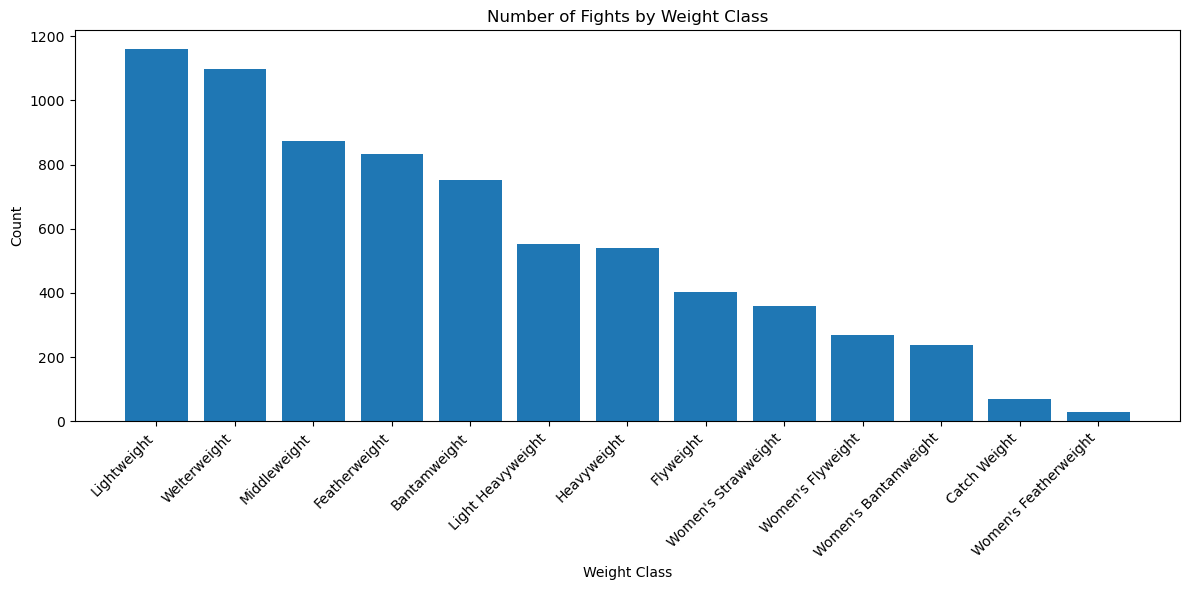

In [23]:
# Bar graph for Weight Class 
counts = ufc_data['weight_class'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(counts.index, counts.values)
ax.set_title('Number of Fights by Weight Class')
ax.set_xlabel('Weight Class')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

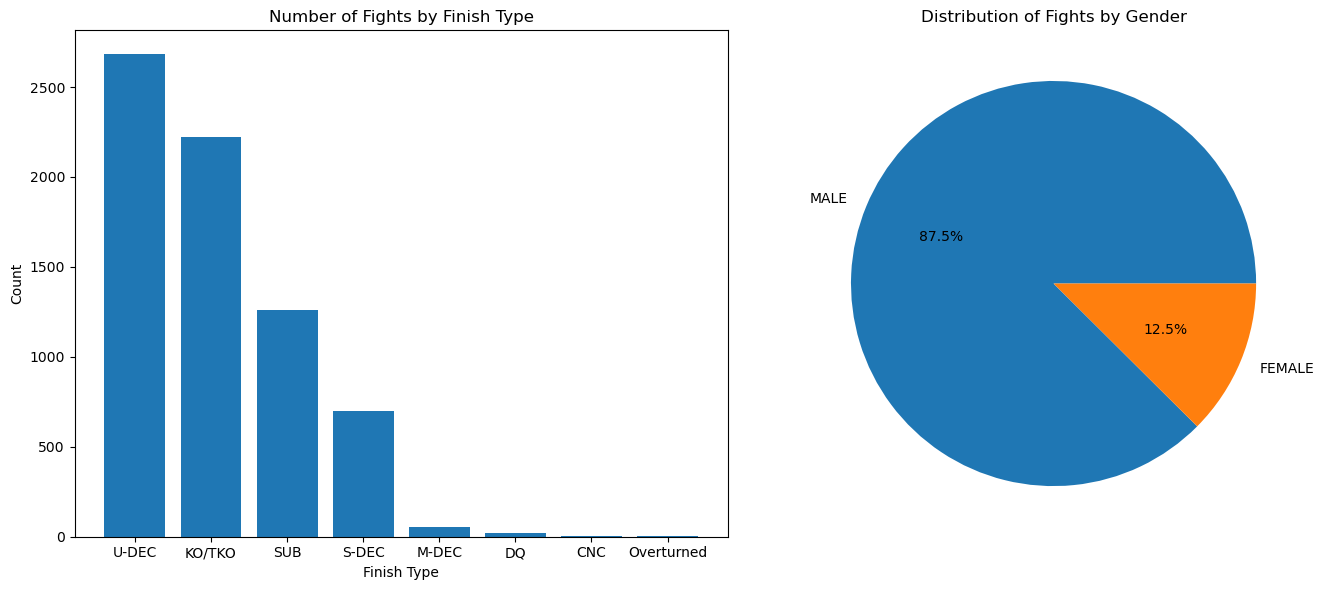

In [24]:
# Bar graph for Finish Types
counts = ufc_data['finish'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar Graph for finish types
ax1.bar(counts.index, counts.values)
ax1.set_title('Number of Fights by Finish Type')
ax1.set_xlabel('Finish Type')
ax1.set_ylabel('Count')

# Pie chart for portion of fights by gender
gender_count = ufc_data['gender'].value_counts()
ax2.pie(gender_count.values, labels=gender_count.index, autopct='%1.1f%%')
ax2.set_title('Distribution of Fights by Gender')

plt.tight_layout()
plt.show()

Now that we have a general understanding of the dataset, we can explore relationships and correlations between physical attributes, ranking, records, fighting style and winning. 

In [25]:
ufc_data.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,Blue,False,Middleweight,MALE,5,0,3,0,3.52,0.44,0.9,1.45,0.30,4,2,18,0,0,0,1,4,2,0,7,Orthodox,187.96,190.50,185,3,0,0,4.03,0.48,0.1,0.05,0.09,9,5,66,12,0,1,7,5,0,0,13,Switch,193.04,203.20,185,36,29,-3,3,-5,-6,-3,-48,-12,-1,2,-5.08,-12.70,-7,-0.51,0.8,1.40,NaN,NaN,KO/TKO,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,Red,False,Women's Flyweight,FEMALE,3,0,7,0,4.56,0.53,0.1,1.56,0.45,7,2,34,0,0,2,4,5,0,0,11,Switch,165.10,165.10,125,2,0,1,4.11,0.41,0.7,0.40,0.35,5,5,45,3,0,1,5,0,2,0,8,Orthodox,165.10,167.64,125,32,27,-2,7,2,3,-3,-11,-3,5,-2,0.00,-2.54,-5,0.45,-0.6,1.16,NaN,NaN,KO/TKO,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,Red,False,Welterweight,MALE,3,3,0,0,5.11,0.43,0.6,1.06,0.30,2,10,40,0,0,0,2,4,2,0,8,Orthodox,182.88,193.04,170,0,3,0,2.02,0.40,1.0,3.11,0.47,4,7,47,1,0,0,6,0,8,0,14,Southpaw,185.42,190.50,170,38,36,3,-3,-2,-6,3,-7,-1,4,-6,-2.54,2.54,-2,3.09,-0.4,-2.05,NaN,NaN,SUB,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,Blue,False,Featherweight,MALE,3,0,1,0,8.67,0.64,0.0,0.00,0.00,1,0,1,0,0,0,0,1,0,0,1,Orthodox,175.26,182.88,145,1,0,0,6.18,0.48,0.7,1.73,0.43,3,8,36,0,0,2,1,3,4,0,10,Southpaw,185.42,187.96,145,36,30,-1,1,-2,-9,-8,-35,0,-2,-4,-10.16,-5.08,-6,2.49,-0.7,-1.73,NaN,NaN,KO/TKO,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,Blue,False,Middleweight,MALE,3,0,2,0,6.10,0.64,0.0,0.29,1.00,2,1,9,0,0,0,0,2,0,0,2,Orthodox,198.12,200.66,185,0,4,1,3.28,0.44,0.3,1.65,0.41,3,0,9,0,0,0,0,3,1,0,4,Orthodox,187.96,203.20,185,28,33,0,-2,-1,-2,1,0,0,-1,-1,10.16,-2.54,5,2.82,-0.3,-1.36,NaN,NaN,KO/TKO,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


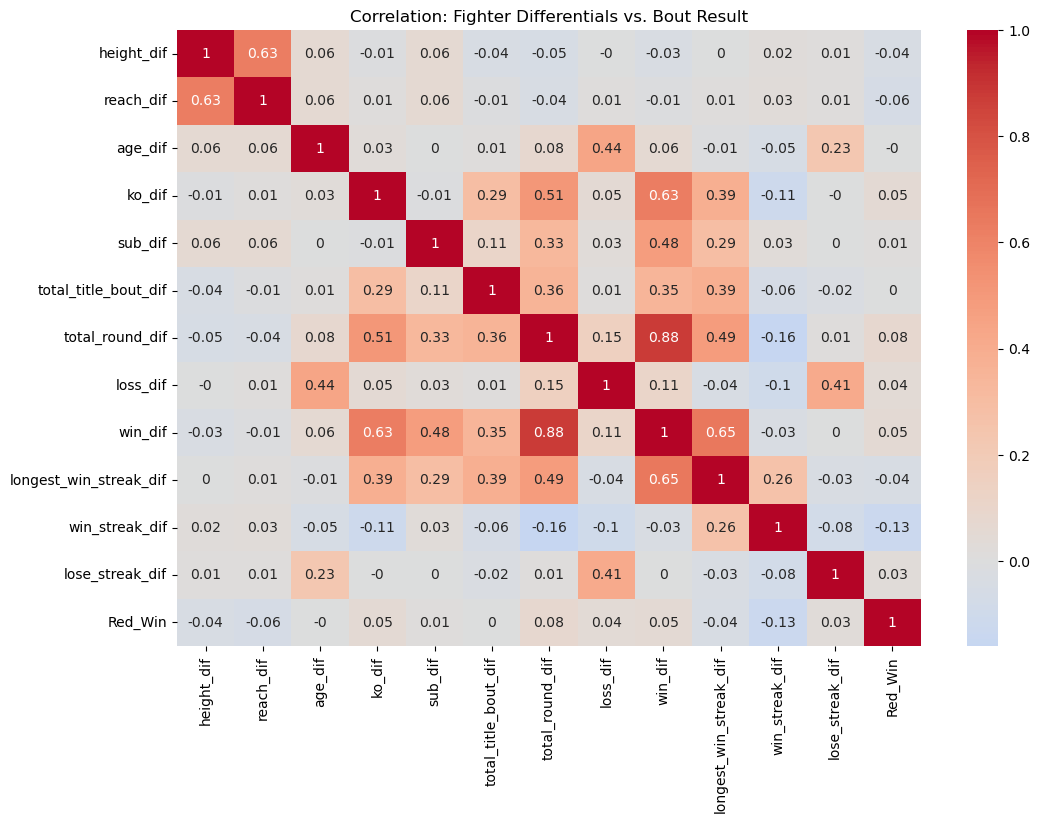

In [26]:
# Plot Heatmap for fighter differentials and bout results
ufc_data['Red_Win'] = (ufc_data['Winner'] == 'Red').astype(int)

isolated_cols = ['height_dif', 'reach_dif', 'age_dif', 'ko_dif', 'sub_dif', 
                'total_title_bout_dif', 'total_round_dif', 'loss_dif', 'win_dif', 'longest_win_streak_dif', 
                'win_streak_dif', 'lose_streak_dif'] + ['Red_Win']

corr_matrix = ufc_data[isolated_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(12,8)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation: Fighter Differentials vs. Bout Result')
plt.show()


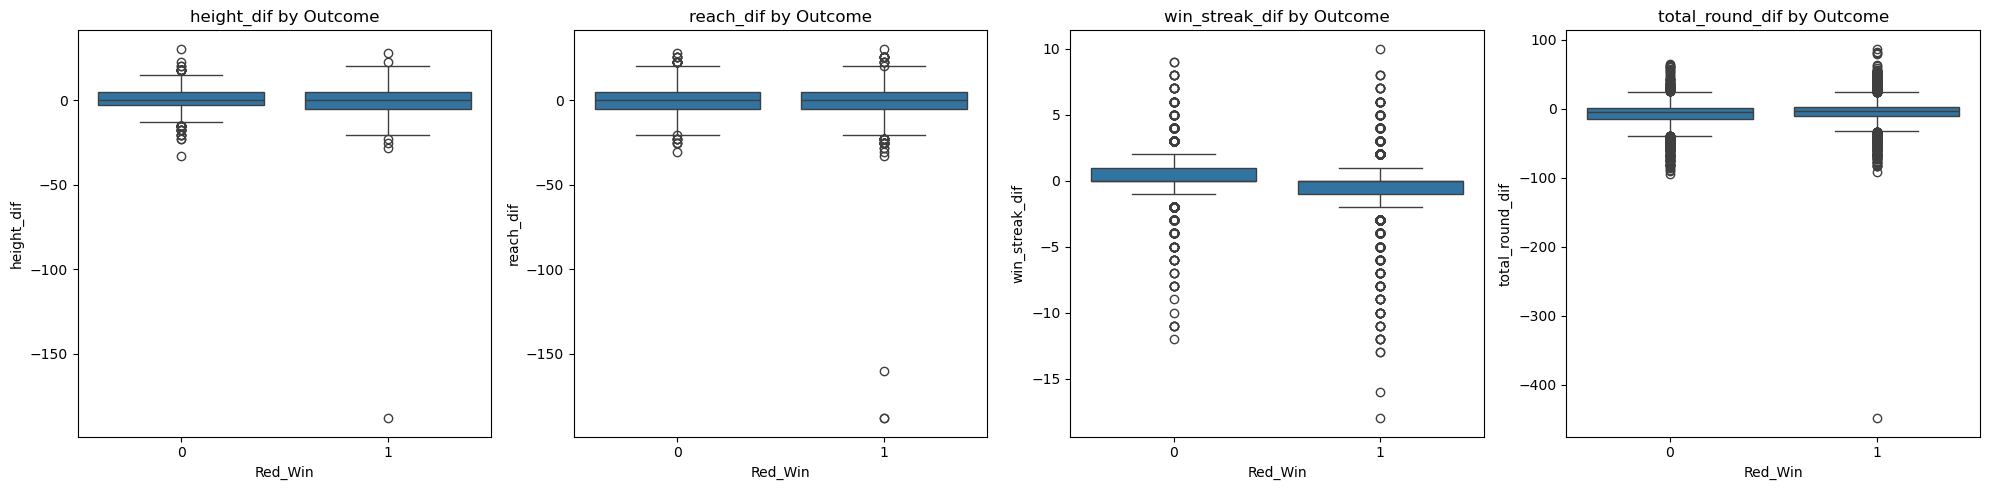

In [27]:
# Box plot for Winners / Losers of bout and Total Round / Win Streak / Reach / Height differentials
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

diffs = ['height_dif', 'reach_dif', 'win_streak_dif', 'total_round_dif']

for ax, col in zip(axes, diffs):
    sns.boxplot(data=ufc_data, x='Red_Win', y=col, ax=ax)
    ax.set_title(f'{col} by Outcome')

plt.tight_layout()
plt.show()

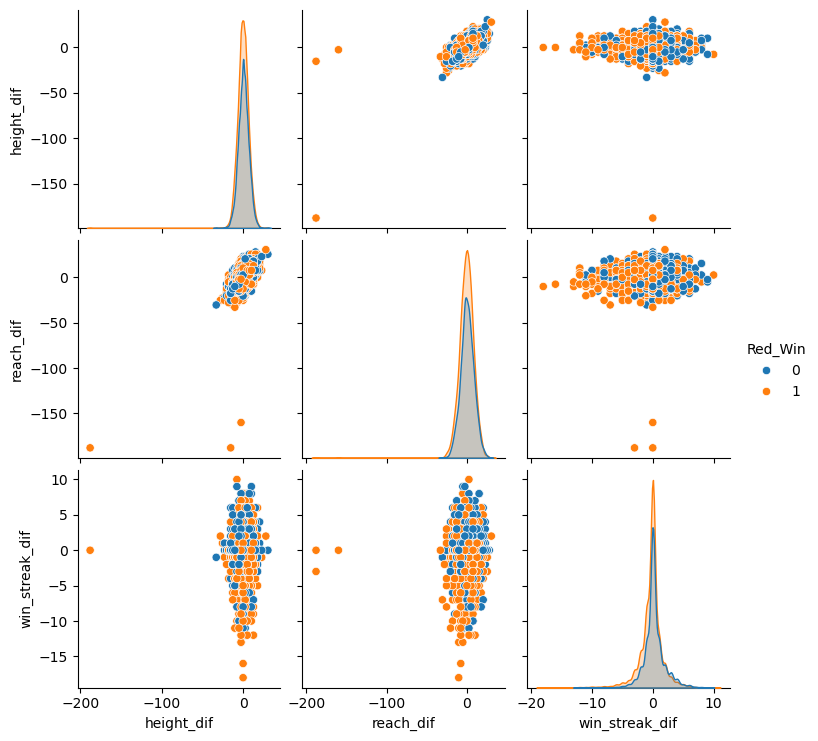

In [28]:
sns.pairplot(ufc_data[['height_dif', 'reach_dif', 'win_streak_dif', 'Red_Win']], hue='Red_Win')